### 실습 1. 전처리 데이터 불러오기

 

해야 할 일

 

먼저 Chapter 01에서 만든 CSV 파일을 pandas로 불러옵니다.

 

처음부터 단어를 분리하지 말고 데이터가 정상적으로 연결되는지 먼저 확인합니다.

In [1]:
import pandas as pd

# CSV 파일 불러오기
df_books = pd.read_csv(
    "book_bestseller_clean.csv",
    encoding="utf-8-sig"
)

# 1. 전체 행과 컬럼 개수
print("1. shape")
print(df_books.shape)

# 2. 컬럼 이름
print("\n2. columns")
print(df_books.columns)

# 3. 앞의 5행
print("\n3. head")
print(df_books.head())

# 4. '상품명' 컬럼 존재 여부
print("\n4. '상품명' 컬럼 존재 여부")
print("상품명" in df_books.columns)

1. shape
(199, 8)

2. columns
Index(['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야'], dtype='str')

3. head
   순위         판매상품ID         상품명    판매가   저자   출판사         발행일     분야
0   1  S000000610612      소년이 온다  13500   한강    창비  2014-05-19     소설
1   2  S000001632467          모순  11700  양귀자    쓰다  2013-04-01     소설
2   3  S000216262757  결국 국민이 합니다  19800  이재명  오마이북  2025-04-15  정치/사회
3   4  S000216111714         혼모노  16200  성해나    창비  2025-03-28     소설
4   5  S000200550189          급류  12600  정대건   민음사  2022-12-22     소설

4. '상품명' 컬럼 존재 여부
True


### 실행 결과 요약

- 데이터 불러오기: `book_bestseller_clean.csv` 파일을 `df_books`로 불러왔다.
- 데이터 크기 확인: 총 **199행, 8개 컬럼**으로 구성되어 있다.
- 컬럼 확인: 순위, 판매상품ID, 상품명, 판매가, 저자, 출판사, 발행일, 분야 컬럼이 있다.
- 데이터 확인: 앞의 5행이 정상적으로 출력되었다.
- 상품명 컬럼 확인: `'상품명' in df_books.columns` 결과가 `True`로 나와 `상품명` 컬럼이 존재함을 확인했다.

### 실습 2. 분석할 도서 제목 확인하기

 

단어 분석을 시작하기 전에 상품명 데이터가 어떤 형태인지 직접 확인합니다.

In [2]:
# 1. 상품명 일부 확인
print("1. 상품명 앞의 20개")
print(df_books["상품명"].head(20))

# 2. 상품명 결측치 개수 확인
print("\n2. 상품명 결측치 개수")
print(df_books["상품명"].isna().sum())

# 3. 상품명을 문자열로 정리
titles = (
    df_books["상품명"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# 정리된 제목 앞의 5개 확인
print("\n3. 정리된 상품명 앞의 5개")
print(titles.head())

# 4. 비어 있는 제목 제외
titles = titles[titles != ""]

# 실제 사용할 제목 개수 확인
print("\n4. 사용할 제목 개수")
print(len(titles))

1. 상품명 앞의 20개
0                        소년이 온다
1                            모순
2                    결국 국민이 합니다
3                           혼모노
4                            급류
5                      초역 부처의 말
6                 청춘의 독서(특별증보판)
7                  어른의 행복은 조용하다
8                         채식주의자
9      단 한 번의 삶(강물에디션 활판인쇄 한정판)
10                     작별하지 않는다
11                          스토너
12           해커스 토익 기출 VOCA(보카)
13    다크 심리학(20만 부 한정판 스페셜 에디션)
14                 트렌드 코리아 2026
15                         위버멘쉬
16                          가공범
17                       듀얼 브레인
18         행동하지 않으면 인생은 바뀌지 않는다
19                  절창(화이트 에디션)
Name: 상품명, dtype: str

2. 상품명 결측치 개수
0

3. 정리된 상품명 앞의 5개
0        소년이 온다
1            모순
2    결국 국민이 합니다
3           혼모노
4            급류
Name: 상품명, dtype: str

4. 사용할 제목 개수
199


### 실행 결과 요약

- 제목 데이터 확인: `상품명` 앞의 20개를 확인해 제목 데이터의 형태를 살펴봤다.
- 결측치 확인: `상품명` 컬럼에 비어 있는 값이 있는지 확인했다.
- 문자열 전처리: 결측치를 빈 문자열로 바꾸고, 문자열로 변환한 뒤 앞뒤 공백을 제거했다.
- 분석 대상 정리: 비어 있는 제목을 제외하고 실제 단어 분석에 사용할 제목 개수를 확인했다.

### 실습 3. Dictionary로 단어 빈도 원리 이해하기

- 단어를 하나씩 확인하면서 몇 번 등장했는지 세는 방법을 연습한다.
- 처음 나온 단어는 Dictionary에 `1`로 저장한다.
- 이미 나온 단어는 기존 횟수에 `1`을 더한다.
- 모든 단어를 확인한 뒤 각 단어의 등장 횟수를 확인한다.

In [3]:
# 단어 빈도 확인을 위한 예시 단어
sample_words = [
    "데이터",
    "분석",
    "파이썬",
    "데이터",
    "AI",
    "분석",
    "데이터"
]

# 단어별 등장 횟수를 저장할 빈 Dictionary 만들기
word_counts = {}

# 단어를 하나씩 확인하면서 등장 횟수 세기
for word in sample_words:
    if word in word_counts:
        # 이미 나온 단어라면 기존 횟수에 1 더하기
        word_counts[word] += 1
    else:
        # 처음 나온 단어라면 1로 시작하기
        word_counts[word] = 1

# 최종 단어 빈도 확인
print("단어 빈도 결과")
print(word_counts)

단어 빈도 결과
{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


In [4]:
# 단어 빈도 확인을 위한 예시 단어
sample_words = [
    "데이터",
    "분석",
    "파이썬",
    "데이터",
    "AI",
    "분석",
    "데이터"
]

# 단어별 등장 횟수를 저장할 빈 Dictionary 만들기
word_counts = {}

# get()을 사용해 단어 등장 횟수 세기
for word in sample_words:
    word_counts[word] = word_counts.get(word, 0) + 1

# 최종 단어 빈도 확인
print("단어 빈도 결과")
print(word_counts)

단어 빈도 결과
{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


### 실행 결과 요약

- 단어 빈도 확인: 예시 단어를 하나씩 확인해 등장 횟수를 셌다.
- 빈도 결과: `데이터`는 3번, `분석`은 2번, `파이썬`과 `AI`는 각각 1번 등장했다.
- Dictionary 활용: 단어를 key로, 등장 횟수를 value로 저장하는 방식을 확인했다.
- 원리 이해: 같은 단어가 다시 나오면 기존 횟수에 1을 더하는 방식으로 빈도를 계산했다.

### 실습 4. Counter로 같은 작업 간단하게 처리하기

 

Python에는 빈도 계산을 도와주는 Counter가 있습니다.

### 실습 내용

- `Counter`를 사용해 단어별 등장 횟수를 더 간단하게 계산한다.
- `most_common()`을 사용하면 많이 등장한 단어부터 확인할 수 있다.
- `most_common(3)`처럼 숫자를 넣으면 상위 몇 개만 확인할 수 있다.
- Dictionary로 빈도 계산 원리를 이해한 뒤, `Counter`로 같은 작업을 더 편리하게 처리하는 방법을 배운다.

In [5]:
from collections import Counter

# sample_words의 단어별 등장 횟수 계산
sample_counter = Counter(sample_words)

# 전체 단어 빈도 확인
print("전체 단어 빈도")
print(sample_counter)

# 많이 등장한 순서대로 확인
print("\n많이 등장한 순서")
print(sample_counter.most_common())

# 상위 3개 단어 확인
print("\n상위 3개 단어")
print(sample_counter.most_common(3))

전체 단어 빈도
Counter({'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1})

많이 등장한 순서
[('데이터', 3), ('분석', 2), ('파이썬', 1), ('AI', 1)]

상위 3개 단어
[('데이터', 3), ('분석', 2), ('파이썬', 1)]


### 실행 결과 요약

- 단어 빈도 계산: `Counter`를 사용해 각 단어의 등장 횟수를 계산했다.
- 빈도 순서 확인: `most_common()`을 사용해 많이 등장한 단어부터 확인했다.
- 상위 단어 확인: `most_common(3)`을 사용해 상위 3개 단어만 확인했다.
- 결과 확인: `데이터`가 3번으로 가장 많이 등장했고, 다음으로 `분석`이 2번 등장했다.

### 실습 5. pandas value_counts()로 빈도 확인하기

- `value_counts()`를 사용해 같은 값이 몇 번 등장했는지 확인한다.
- `sample_words`를 pandas `Series`로 만든 뒤 단어별 빈도를 계산한다.
- `Dictionary`, `Counter`, `value_counts()`는 모두 빈도를 확인하는 방법이지만 사용하는 방식이 다르다.
- 이번 실습에서는 pandas 데이터 분석에서 자주 사용하는 `value_counts()` 방법을 익힌다.

In [6]:
import pandas as pd

# sample_words를 pandas Series로 만들기
sample_series = pd.Series(sample_words)

# 단어별 등장 횟수 확인
print("단어 빈도 결과")
print(sample_series.value_counts())

단어 빈도 결과
데이터    3
분석     2
파이썬    1
AI     1
Name: count, dtype: int64


### 실행 결과 요약

- 단어 빈도 계산: `value_counts()`를 사용해 각 단어의 등장 횟수를 계산했다.
- 결과 확인: `데이터`는 3번, `분석`은 2번, `파이썬`과 `AI`는 각각 1번 등장했다.
- pandas 활용: `Series`에서 같은 값의 개수를 간단하게 확인할 수 있음을 확인했다.

### Counter와 value_counts() 비교

- `Counter`: Python 리스트나 문자열처럼 일반적인 Python 데이터를 간단하게 셀 때 편리하다.
- `value_counts()`: pandas `Series`에서 값의 빈도를 바로 계산할 수 있어 데이터 분석 작업에 더 자연스럽다.
- 대량 데이터 분석: DataFrame과 함께 작업하고 있다면 `value_counts()`가 후속 정렬, 필터링, 집계로 이어가기 편하다.
- 정리: Python 리스트 중심이면 `Counter`, pandas 데이터 분석 중심이면 `value_counts()`를 사용하는 것이 이해하기 쉽고 실무 흐름에도 잘 맞는다.

### 실습 6. 실제 도서 제목을 간단하게 단어로 나누기

- 실제 `상품명` 데이터를 대상으로 간단한 단어 분리를 연습한다.
- 정규표현식을 사용해 한글, 영어, 숫자로 이루어진 부분을 토큰으로 추출한다.
- 영어는 소문자로 바꿔 같은 단어를 일정하게 처리한다.
- 이 방법은 빠르고 간단하지만 `시대의`, `python으로`처럼 사람이 생각하는 의미 단위와 다르게 나눠질 수 있다.
- 따라서 이번 단계에서는 완벽한 분석보다 토큰화와 빈도 집계의 흐름을 이해하는 데 목적이 있다.

In [7]:
import re

# 간단한 토큰화 함수 만들기
def simple_tokenize(text):
    # 1. text를 문자열로 바꾸기
    text = str(text)
    
    # 2. 영어는 소문자로 바꾸기
    text = text.lower()
    
    # 3. 한글, 영어, 숫자로 이루어진 단어만 추출하기
    tokens = re.findall(r"[가-힣A-Za-z0-9]+", text)
    
    # 4. 추출한 단어 목록 반환하기
    return tokens


# 테스트용 제목
sample_title = "AI 시대의 데이터 분석, Python으로 시작하기!"

# 함수 실행
sample_tokens = simple_tokenize(sample_title)

# 결과 확인
print("원본 제목")
print(sample_title)

print("\n토큰화 결과")
print(sample_tokens)

원본 제목
AI 시대의 데이터 분석, Python으로 시작하기!

토큰화 결과
['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']


### 실행 결과 요약

- 원본 확인: 테스트용 제목이 정상적으로 입력된 것을 확인했다.
- 토큰화 결과: 한글, 영어로 이루어진 단어가 각각 분리되었다.
- 소문자 변환: `AI`는 `ai`로 변환되었다.
- 한계 확인: `시대의`, `python으로`처럼 조사나 어미가 붙은 형태로 남아 있어 단순 토큰화의 한계를 확인할 수 있었다.

### 모든 제목에서 단어 추출하기

- 모든 도서 제목을 하나씩 확인하면서 `simple_tokenize()`로 단어를 추출한다.
- 추출한 단어들은 `simple_words`라는 하나의 리스트에 모두 모은다.
- `append()`는 리스트 자체를 넣지만, `extend()`는 리스트 안의 단어들을 하나씩 이어 붙인다.
- 빈도 분석에서는 단어를 한 리스트에 모아야 하므로 `extend()`가 더 적합하다.

In [8]:
# 모든 제목에서 추출한 단어를 저장할 빈 리스트 만들기
simple_words = []

# titles에 있는 제목을 하나씩 확인
for title in titles:
    
    # 제목을 단어로 나누기
    words = simple_tokenize(title)
    
    # 추출한 단어들을 simple_words에 하나씩 추가
    simple_words.extend(words)


# 전체 단어 수 확인
print("전체 단어 수:", len(simple_words))

# 앞의 50개 단어 확인
print("\n앞의 50개 단어")
print(simple_words[:50])


# append()와 extend() 차이 확인
example_append = []
example_append.append(["데이터", "분석"])

print("\nappend() 결과")
print(example_append)


example_extend = []
example_extend.extend(["데이터", "분석"])

print("\nextend() 결과")
print(example_extend)

전체 단어 수: 760

앞의 50개 단어
['소년이', '온다', '모순', '결국', '국민이', '합니다', '혼모노', '급류', '초역', '부처의', '말', '청춘의', '독서', '특별증보판', '어른의', '행복은', '조용하다', '채식주의자', '단', '한', '번의', '삶', '강물에디션', '활판인쇄', '한정판', '작별하지', '않는다', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '20만', '부', '한정판', '스페셜', '에디션', '트렌드', '코리아', '2026', '위버멘쉬', '가공범', '듀얼', '브레인', '행동하지', '않으면', '인생은']

append() 결과
[['데이터', '분석']]

extend() 결과
['데이터', '분석']


### 실습 8. 실제 데이터에서 Counter로 빈도 확인하기

- `Counter`를 사용해 실제 도서 제목에서 추출한 단어의 빈도를 계산한다.
- 가장 많이 등장한 상위 30개 단어를 확인하고, pandas DataFrame으로 표 형태로 정리한다.
- 바로 Word Cloud를 만들지 않고 상위 단어를 먼저 확인해 불필요한 표현이나 이상한 분리가 있는지 살펴본다.
- 이 결과를 바탕으로 한 글자 단어, 조사·어미, 숫자, `개정판`, `세트` 같은 표현을 어떻게 처리할지 다음 전처리 방향을 정한다.

In [9]:
from collections import Counter
import pandas as pd

# simple_words의 단어별 등장 횟수 계산
simple_counter = Counter(simple_words)

# 가장 많이 등장한 상위 30개 단어 확인
print("상위 30개 단어")
print(simple_counter.most_common(30))

# 상위 30개 단어를 표 형태의 DataFrame으로 만들기
simple_top30 = pd.DataFrame(
    simple_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 결과 확인
print("\n상위 30개 단어 표")
print(simple_top30)

상위 30개 단어
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5), ('나는', 5), ('내가', 5), ('대하여', 4), ('싶은', 4), ('lc', 4), ('rc', 4), ('1', 4), ('단', 3), ('한정판', 3), ('않는다', 3), ('voca', 3), ('트렌드', 3), ('2026', 3), ('30만', 3), ('돈의', 3), ('때', 3), ('2025', 3), ('일본어', 3), ('없는', 3), ('필사', 3)]

상위 30개 단어 표
      단어  빈도
0    에디션  12
1      부   9
2     기념   8
3    리커버   8
4      한   7
5    해커스   7
6     위한   7
7      말   6
8     토익   6
9    스페셜   5
10    나는   5
11    내가   5
12   대하여   4
13    싶은   4
14    lc   4
15    rc   4
16     1   4
17     단   3
18   한정판   3
19   않는다   3
20  voca   3
21   트렌드   3
22  2026   3
23   30만   3
24    돈의   3
25     때   3
26  2025   3
27   일본어   3
28    없는   3
29    필사   3


### 실행 결과 요약

- 단어 빈도 확인: 실제 도서 제목에서 추출한 단어 중 상위 30개를 확인했다.
- 주요 단어 확인: `에디션`, `기념`, `리커버`, `해커스`, `토익` 등이 자주 등장했다.
- 분석 목적과 무관한 표현 확인: `에디션`, `기념`, `리커버`, `스페셜`, `한정판`처럼 책의 내용보다 판형이나 마케팅 성격을 나타내는 표현도 많이 포함되어 있었다.
- 추가 전처리 필요 확인: `한`, `부`, `1`, `2026`, `2025`처럼 분석 목적에 따라 불필요할 수 있는 단어나 숫자도 포함되어 있었다.
- 형태 확인: `나는`, `내가`, `위한`, `않는다`처럼 조사나 어미가 붙은 형태도 남아 있었다.
- 다음 단계 판단: Word Cloud를 만들기 전에 불용어 제거와 형태소 분석을 진행할 필요가 있음을 확인했다.

### 실습 9. pandas로도 실제 단어 빈도 확인하기

- `simple_words`를 pandas `Series`로 변환한 뒤 `value_counts()`로 단어 빈도를 확인한다.
- 앞에서 사용한 `Counter` 결과와 비교해 상위 단어의 빈도가 같은지 검증한다.
- 두 방법의 결과가 같으면 단어 리스트가 정상적으로 만들어졌다고 볼 수 있다.
- 결과가 다르면 다음 단계로 넘어가기 전에 단어 생성 과정과 전처리 과정을 다시 확인한다.

In [10]:
import pandas as pd

# simple_words 리스트를 pandas Series로 변환
simple_word_series = pd.Series(simple_words)

# pandas value_counts()로 상위 30개 단어 확인
print("value_counts() 상위 30개")
print(simple_word_series.value_counts().head(30))

# Counter와 pandas 결과 비교
print("\nCounter 상위 10개")
print(simple_counter.most_common(10))

print("\nvalue_counts() 상위 10개")
print(simple_word_series.value_counts().head(10))

value_counts() 상위 30개
에디션     12
부        9
기념       8
리커버      8
한        7
해커스      7
위한       7
말        6
토익       6
스페셜      5
나는       5
내가       5
대하여      4
싶은       4
lc       4
rc       4
1        4
단        3
한정판      3
않는다      3
voca     3
트렌드      3
2026     3
30만      3
돈의       3
때        3
2025     3
일본어      3
없는       3
필사       3
Name: count, dtype: int64

Counter 상위 10개
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5)]

value_counts() 상위 10개
에디션    12
부       9
기념      8
리커버     8
한       7
해커스     7
위한      7
말       6
토익      6
스페셜     5
Name: count, dtype: int64


### 실행 결과 요약

- pandas 확인: `value_counts()`를 사용해 실제 단어 빈도 상위 30개를 확인했다.
- 결과 비교: `Counter`와 `value_counts()`의 상위 10개 단어와 빈도가 모두 같았다.
- 검증 결과: 두 방법에서 같은 결과가 나와 `simple_words`의 단어 빈도 집계가 정상적으로 이루어진 것을 확인했다.
- 다음 단계: 빈도 집계가 일치하므로 이후 불용어 제거와 형태소 분석 단계로 진행할 수 있다.

### 실습 10. 왜 형태소 분석이 필요한가?

- 한국어는 조사나 어미가 붙기 때문에 단순 공백 기준으로는 같은 의미의 단어가 서로 다르게 처리될 수 있다.
- 예를 들어 `데이터를`, `데이터가`, `데이터의`는 모두 핵심 의미가 `데이터`이지만 문자열은 다르다.
- `은`, `는`, `이`, `가`, `을`, `를`, `의`처럼 분석에 중요하지 않은 조사도 함께 포함될 수 있다.
- 따라서 도서 제목의 주요 주제를 보기 위해 형태소 분석을 사용해 명사 중심으로 단어를 추출한다.

### 실습 11. Kiwi 형태소 분석기 설치하기

 

한글 형태소 분석 도구는 여러 가지가 있습니다.

 

이번 실습에서는 Windows 환경에서도 비교적 설치가 간단한 kiwipiepy를 사용합니다.

 

터미널에서 현재 사용하는 Python 가상환경이 활성화되어 있는지 확인한 뒤 설치합니다.

 

python -m pip install kiwipiepy

 

설치 확인은 다음과 같이 할 수 있습니다.

 

python -m pip show kiwipiepy

 

Notebook에서 바로 설치했다면 커널 재시작이 필요한 경우도 있습니다.

### kiwipiepy 설치 및 확인

Windows와 VS Code Notebook 환경에서 한국어 도서 제목의 명사를 추출하기 위해 `kiwipiepy`를 설치한다.

#### 1. 현재 가상환경에 설치

VS Code 터미널에서 현재 가상환경이 활성화되어 있는지 확인한 뒤 다음 명령어를 실행한다.

```bash
python -m pip install kiwipiepy

python -m pip를 사용하면 현재 실행 중인 Python 환경에 설치되기 때문에 초보자에게 더 안전한 방법이다.

2. 설치 여부 확인

설치가 끝난 뒤 다음 명령어로 설치 여부를 확인한다.

python -m pip show kiwipiepy

정상적으로 설치되었다면 버전과 설치 위치 등의 정보가 출력된다.

Notebook에서도 다음 코드로 불러오기가 가능한지 확인할 수 있다.

from kiwipiepy import Kiwi

kiwi = Kiwi()

print("kiwipiepy import 성공")

에러 없이 문구가 출력되면 정상적으로 설치된 것이다.

3. ModuleNotFoundError가 발생할 때 확인할 항목

ModuleNotFoundError가 발생하면 kiwipiepy가 설치된 Python과 Notebook이 사용하는 Python이 서로 다른지 확인한다.

Notebook에서 다음 코드를 실행한다.

import sys

print(sys.executable)

터미널에서도 Python 경로를 확인한다.

python -c "import sys; print(sys.executable)"

두 경로가 다르면 kiwipiepy가 다른 가상환경에 설치된 것일 수 있다.

### 실행 결과 요약

- 설치 완료: `kiwipiepy`, `kiwipiepy_model`, `tqdm` 패키지가 정상적으로 설치되었다.
- 버전 확인: `kiwipiepy`는 `0.23.2`, `kiwipiepy_model`은 `0.23.0` 버전이 설치되었다.
- 빌드 확인: `kiwipiepy_model` wheel 생성이 정상적으로 완료되었다.
- 결과 확인: 오류 없이 `Successfully installed`가 출력되어 설치가 성공적으로 끝난 것을 확인했다.

### 실습 12. Kiwi로 한 문장 품사 확인하기

- `Kiwi`를 사용해 짧은 문장을 형태소 단위로 나누고 각 단어의 품사를 확인한다.
- `token.form`으로 단어를, `token.tag`로 품사 태그를 확인할 수 있다.
- 이번 분석에서는 주로 일반 명사(`NNG`), 고유 명사(`NNP`), 영문 표현(`SL`)을 활용한다.
- 형태소 분석 결과는 항상 완벽하지 않으므로 신조어, 인물명, 영문 약어, 브랜드명 등이 어떻게 분석되는지 실제 결과를 직접 확인해야 한다.

In [11]:
from kiwipiepy import Kiwi

# Kiwi 형태소 분석기 만들기
kiwi = Kiwi()

# 테스트할 문장
sample_title = "AI 시대의 데이터 분석을 위한 파이썬"

# 문장을 형태소 단위로 분석
tokens = kiwi.tokenize(sample_title)

# 전체 분석 결과 확인
print("전체 토큰 결과")
print(tokens)

# 각 단어와 품사 태그 확인
print("\n단어와 품사 태그")
for token in tokens:
    print(token.form, token.tag)

전체 토큰 결과
[Token(form='AI', tag='SL', start=0, len=2), Token(form='시대', tag='NNG', start=3, len=2), Token(form='의', tag='JKG', start=5, len=1), Token(form='데이터', tag='NNG', start=7, len=3), Token(form='분석', tag='NNG', start=11, len=2), Token(form='을', tag='JKO', start=13, len=1), Token(form='위하', tag='VV', start=15, len=2), Token(form='ᆫ', tag='ETM', start=16, len=1), Token(form='파이썬', tag='NNP', start=18, len=3)]

단어와 품사 태그
AI SL
시대 NNG
의 JKG
데이터 NNG
분석 NNG
을 JKO
위하 VV
ᆫ ETM
파이썬 NNP


### 실습 13. 명사 중심으로 단어 추출하기

- `Kiwi`로 문장을 형태소 분석한 뒤 필요한 품사만 선택해 단어를 추출한다.
- 이번 실습에서는 일반 명사(`NNG`), 고유 명사(`NNP`), 영문 표현(`SL`)만 사용한다.
- 추출한 단어는 앞뒤 공백을 제거하고, 영문은 소문자로 통일한다.
- `AI`와 `ai`처럼 같은 의미의 단어가 따로 집계되지 않도록 형태를 맞춘다.
- 최종 결과는 이후 단어 빈도 분석에 사용할 수 있도록 리스트 형태로 반환한다.

In [12]:
# 사용할 품사 태그 지정
TARGET_TAGS = {"NNG", "NNP", "SL"}

# 명사 중심으로 단어를 추출하는 함수
def extract_words(text):
    result = []

    # 문장을 Kiwi로 형태소 분석
    for token in kiwi.tokenize(str(text)):

        # 일반 명사, 고유 명사, 영문 표현만 선택
        if token.tag in TARGET_TAGS:

            # 앞뒤 공백 제거 + 영문 소문자 통일
            word = token.form.strip().lower()

            # 결과 리스트에 추가
            result.append(word)

    return result


# 함수 테스트
test_result = extract_words("AI 시대의 데이터 분석을 위한 파이썬")

print("추출 결과")
print(test_result)

추출 결과
['ai', '시대', '데이터', '분석', '파이썬']


In [14]:
test_result_2 = extract_words("동해물과 백두산이 마르고 닳도록 하느님이 보우하사 우리나라 만세무궁화 삼천리 화려 강산 대한 사람 대한으로 길이 보전하세")

test_result_2

['동해',
 '물',
 '백두산',
 '하느님',
 '보우',
 '나라',
 '만세',
 '무궁화',
 '삼천리',
 '강산',
 '사람',
 '대한',
 '보전']

### 실행 결과 요약

- 명사 추출 확인: `extract_words()` 함수를 사용해 문장에서 필요한 단어만 추출했다.
- 품사 선택 결과: `AI`, `시대`, `데이터`, `분석`, `파이썬`이 분석 대상으로 추출되었다.
- 소문자 통일: `AI`는 `ai`로 변환되어 대소문자 차이로 따로 집계되지 않도록 정리되었다.
- 결과 확인: 조사와 동사 등은 제외되고, 주요 명사와 영문 표현 중심으로 추출된 것을 확인했다.

### 실습 14. 최소 글자수 필터링 적용하기

- 최소 길이 설정: 분석에 사용할 단어를 기본적으로 **2글자 이상**으로 제한한다.
- 필터링 목적: 한 글자 토큰이 너무 많이 포함되어 결과 해석이 어려워지는 것을 줄인다.
- 포함 예시: `ai`는 2글자이므로 분석에 포함된다.
- 주의점: 2글자 이상이라는 기준은 절대적인 규칙이 아니라 이번 분석을 위한 조건이다.
- 분석 기준: 이번 분석에서는 노이즈를 줄이기 위해 2글자 이상의 명사와 영문 토큰을 사용한다.

In [15]:
# 분석에 사용할 최소 글자 수 설정
MIN_LENGTH = 2

# 명사 중심으로 단어를 추출하는 함수
def extract_words(text):
    result = []

    # 문장을 Kiwi로 형태소 분석
    for token in kiwi.tokenize(str(text)):

        # 일반 명사, 고유 명사, 영문 표현만 선택
        if token.tag in TARGET_TAGS:

            # 앞뒤 공백 제거 + 영문 소문자 통일
            word = token.form.strip().lower()

            # 2글자 이상인 단어만 추가
            if len(word) >= MIN_LENGTH:
                result.append(word)

    return result


# 함수 테스트
test_result = extract_words("AI 시대의 데이터 분석을 위한 파이썬")

print("추출 결과")
print(test_result)

추출 결과
['ai', '시대', '데이터', '분석', '파이썬']


### 실행 결과 요약

- 최소 글자수 적용: 2글자 이상인 단어만 추출하도록 조건을 적용했다.
- 추출 결과: `ai`, `시대`, `데이터`, `분석`, `파이썬`이 남았다.
- 필터링 확인: 테스트 문장에서는 주요 단어가 모두 2글자 이상이라 기존 결과와 동일했다.
- 결과 확인: 설정한 최소 글자수 조건이 정상적으로 적용된 것을 확인했다.

### 실습 15. 모든 도서 제목에서 명사 추출하기

- 전체 제목 분석: 모든 도서 제목에 `extract_words()`를 적용해 명사와 영문 표현을 추출한다.
- 단어 수 확인: 추출된 전체 단어 수와 앞의 일부 단어를 확인한다.
- 빈도 분석: `Counter`를 사용해 많이 등장한 단어를 확인하고, 상위 30개를 DataFrame으로 정리한다.
- 결과 비교: 단순 토큰화 결과와 형태소 분석 결과의 상위 단어를 비교한다.
- 확인 포인트: 조사나 불필요한 표현이 줄었는지, 의미 있는 주제어가 더 잘 보이는지, 중요한 단어가 빠지지는 않았는지 확인한다.

In [16]:
from collections import Counter
import pandas as pd

# 모든 도서 제목에서 추출한 단어를 저장할 빈 리스트
filtered_words = []

# titles의 제목을 하나씩 확인
for title in titles:

    # 형태소 분석을 통해 필요한 단어만 추출
    words = extract_words(title)

    # 추출한 단어를 하나의 리스트에 이어 붙이기
    filtered_words.extend(words)


# 추출된 전체 단어 수 확인
print("추출된 전체 단어 수:", len(filtered_words))

# 앞의 50개 단어 확인
print("\n앞의 50개 단어")
print(filtered_words[:50])


# 단어별 등장 횟수 계산
noun_counter = Counter(filtered_words)

# 상위 30개 단어 확인
print("\n형태소 분석 후 상위 30개 단어")
print(noun_counter.most_common(30))


# 상위 30개 단어를 DataFrame으로 만들기
noun_top30 = pd.DataFrame(
    noun_counter.most_common(30),
    columns=["단어", "빈도"]
)

print("\n형태소 분석 후 상위 30개 단어 표")
display(noun_top30)


# 단순 토큰화 결과와 형태소 분석 결과 비교
print("\n단순 토큰화 상위 10개")
display(simple_top30.head(10))

print("형태소 분석 후 상위 10개")
display(noun_top30.head(10))

추출된 전체 단어 수: 463

앞의 50개 단어
['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '한정판', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '한정판', '스페셜', '에디션', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '에디션', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도']

형태소 분석 후 상위 30개 단어
[('에디션', 14), ('기념', 10), ('토익', 8), ('해커스', 7), ('리커버', 7), ('스페셜', 5), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3), ('한정판', 3), ('voca', 3), ('트렌드', 3), ('남매', 3), ('일본어', 3), ('사람', 3), ('etf', 3), ('사랑', 3), ('어린이', 3), ('세상', 3), ('공략', 3), ('소년', 2), ('국민', 2), ('초역', 2), ('부처', 2), ('증보판', 2), ('어른', 2)]

형태소 분석 후 상위 30개 단어 표


,단어,빈도
0,에디션,14
1,기념,10
2,토익,8
3,해커스,7
4,리커버,7
5,스페셜,5
6,필사,5
7,인생,4
8,수업,4
9,시대,4



단순 토큰화 상위 10개


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5


형태소 분석 후 상위 10개


,단어,빈도
0,에디션,14
1,기념,10
2,토익,8
3,해커스,7
4,리커버,7
5,스페셜,5
6,필사,5
7,인생,4
8,수업,4
9,시대,4


### 실행 결과 요약

- 전체 명사 추출: 모든 도서 제목에 형태소 분석을 적용한 결과 총 **463개 단어**가 추출되었다.
- 단순 토큰화 결과: `에디션`, `부`, `기념`, `리커버`, `한`, `위한`처럼 의미가 불분명하거나 조사·어미 성격이 남아 있는 표현이 상위에 포함되었다.
- 형태소 분석 결과: `부`, `한`, `위한` 같은 표현은 줄고 `인생`, `수업`, `시대`, `사람`, `사랑`처럼 의미 있는 명사가 더 잘 나타났다.
- 빈도 변화: 형태소 분석 후 `에디션`은 12회에서 14회, `기념`은 8회에서 10회, `토익`은 6회에서 8회로 집계되어 단순 토큰화와 차이가 나타났다.
- 불필요한 표현 확인: 형태소 분석 후에도 `에디션`, `기념`, `리커버`, `스페셜`, `한정판`, `증보판`처럼 분석 목적과 직접 관련이 적은 표현이 많이 남아 있었다.
- 한계 확인: `혼모노`가 `혼모`처럼 잘리거나 `강물에디션`처럼 붙어 있는 표현도 있어 형태소 분석 결과가 항상 완벽한 것은 아니었다.
- 다음 단계 판단: 형태소 분석으로 단어가 더 정리되었지만, 최종 주제 분석을 위해서는 불용어 제거와 일부 단어 보정이 추가로 필요하다.

### 실습 16. 불용어 이해하기

- 불용어 의미: 자주 등장하지만 분석 목적에는 큰 도움이 되지 않는 단어를 불용어라고 한다.
- 예시 확인: `세트`, `개정판`, `에디션`, `리커버`, `한정판` 같은 표현이 불용어 후보가 될 수 있다.
- 주의점: 결과를 확인하기 전에 너무 많은 단어를 임의로 제거하면 분석 결과가 왜곡될 수 있다.
- 적용 순서: 먼저 빈도 결과를 확인하고, 원본 제목에서 실제 사용 방식을 살펴본 뒤 분석 목적과 관계가 적다고 판단되는 단어만 불용어에 추가한다.
- 결과 검증: 불용어를 적용한 뒤 빈도 결과가 어떻게 달라졌는지 다시 확인한다.

### 실습 17. 불용어 목록 만들기

- 불용어 설정: `세트`, `개정판`, `에디션`, `리커버`, `한정판`처럼 분석 목적과 관계가 적은 표현을 불용어로 지정한다.
- 품사 필터: 일반 명사(`NNG`), 고유 명사(`NNP`), 영문 표현(`SL`)만 남긴다.
- 길이 필터: 2글자 이상인 단어만 사용한다.
- 불용어 필터: `STOPWORDS`에 포함된 단어는 분석 대상에서 제외한다.
- 주의점: 불용어는 처음부터 많이 넣지 않고, 실제 빈도 결과를 확인하면서 필요한 단어만 추가한다.

In [21]:
# 실제 빈도 결과를 바탕으로 만든 불용어 목록
STOPWORDS = {
    "에디션",
    "기념",
    "리커버",
    "스페셜",
    "한정판",
    "증보판",
    "특별",
    "개정",
    "강물에디션",
}


# 사용할 품사 태그
TARGET_TAGS = {"NNG", "NNP", "SL"}

# 최소 글자 수
MIN_LENGTH = 2


# 불용어를 적용한 단어 추출 함수
def extract_words(text):
    result = []

    # Kiwi로 형태소 분석
    for token in kiwi.tokenize(str(text)):

        # 1. 명사와 영문 표현만 사용
        if token.tag not in TARGET_TAGS:
            continue

        # 앞뒤 공백 제거 + 영어 소문자 통일
        word = token.form.strip().lower()

        # 2. 2글자 미만 단어 제외
        if len(word) < MIN_LENGTH:
            continue

        # 3. 불용어 목록에 있는 단어 제외
        if word in STOPWORDS:
            continue

        # 조건을 모두 통과한 단어 저장
        result.append(word)

    return result

### 실행 결과 요약

- 불용어 설정: 실제 빈도 결과를 바탕으로 `에디션`, `기념`, `리커버`, `스페셜`, `한정판`, `증보판` 등 분석 목적과 관련이 적은 표현을 불용어로 지정했다.
- 품사 필터 적용: 일반 명사(`NNG`), 고유 명사(`NNP`), 영문 표현(`SL`)만 사용하도록 설정했다.
- 길이 필터 적용: 2글자 이상인 단어만 분석 대상으로 남기도록 했다.
- 불용어 필터 적용: `STOPWORDS`에 포함된 단어는 추출 결과에서 제외하도록 했다.
- 함수 정리: 품사, 글자 수, 불용어 조건을 모두 적용하는 `extract_words()` 함수를 완성했다.

### 실습 18. 최종 단어 목록 만들기

- 최종 단어 생성: 모든 도서 제목에 `extract_words()`를 적용해 최종 분석용 단어 목록을 만든다.
- 빈도 계산: `Counter`를 사용해 각 단어의 등장 횟수를 계산한다.
- 상위 단어 정리: 가장 많이 등장한 상위 30개 단어를 DataFrame으로 정리한다.
- 결과 저장: 상위 30개 단어를 `chapter02_top30_words.csv` 파일로 저장한다.
- 파일 확인: `Path().exists()`를 사용해 CSV 파일이 정상적으로 생성되었는지 확인한다.

In [20]:
from collections import Counter
import pandas as pd
from pathlib import Path

# 모든 도서 제목에서 최종 단어 추출
final_words = []

for title in titles:
    final_words.extend(extract_words(title))

# 최종 단어 수와 일부 단어 확인
print("최종 단어 수:", len(final_words))

print("\n앞의 50개 단어")
print(final_words[:50])


# 단어별 빈도 계산
final_counter = Counter(final_words)

# 상위 30개 단어 확인
print("\n상위 30개 단어")
print(final_counter.most_common(30))


# 상위 30개 단어를 DataFrame으로 만들기
top30 = pd.DataFrame(
    final_counter.most_common(30),
    columns=["단어", "빈도"]
)

print("\n상위 30개 단어 표")
display(top30)


# CSV 파일로 저장
top30.to_csv(
    "chapter02_top30_words.csv",
    index=False,
    encoding="utf-8-sig"
)

# 파일이 정상적으로 생성되었는지 확인
print("\n파일 생성 여부")
print(Path("chapter02_top30_words.csv").exists())

최종 단어 수: 417

앞의 50개 단어
['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '어른', '행복', '채식주의자', '활판', '인쇄', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '쇼펜하우어', '인생', '수업', '남매', '행복', '정도', '교보문고', '단독', '안녕', '호의', '자리', '연금', '부자', '수업', '소망', '금지', '심리학']

상위 30개 단어
[('토익', 8), ('해커스', 7), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('voca', 3), ('트렌드', 3), ('남매', 3), ('일본어', 3), ('사람', 3), ('etf', 3), ('사랑', 3), ('어린이', 3), ('세상', 3), ('공략', 3), ('소년', 2), ('국민', 2), ('초역', 2), ('부처', 2), ('어른', 2), ('행복', 2), ('기출', 2), ('보카', 2), ('심리학', 2), ('코리아', 2), ('행동', 2), ('쇼펜하우어', 2)]

상위 30개 단어 표


,단어,빈도
0,토익,8
1,해커스,7
2,필사,5
3,인생,4
4,수업,4
5,시대,4
6,lc,4
7,rc,4
8,voca,3
9,트렌드,3



파일 생성 여부
True


### 실습 19. 상위 단어를 막대그래프로 먼저 확인하기

- 막대그래프 확인: 최종 상위 30개 단어의 빈도를 가로 막대그래프로 시각화한다.
- 목적: Word Cloud를 만들기 전에 단어별 빈도 차이를 더 정확하게 비교한다.
- 한글 설정: Windows에서는 `Malgun Gothic`을 설정해 그래프의 한글이 깨지지 않도록 한다.
- 결과 검증: 빈도가 가장 높은 단어가 표의 결과와 같은지, 막대 길이가 실제 빈도와 자연스럽게 대응하는지 확인한다.
- 활용 방향: 막대그래프로 최종 단어 빈도를 먼저 검증한 뒤 Word Cloud 시각화로 넘어간다.

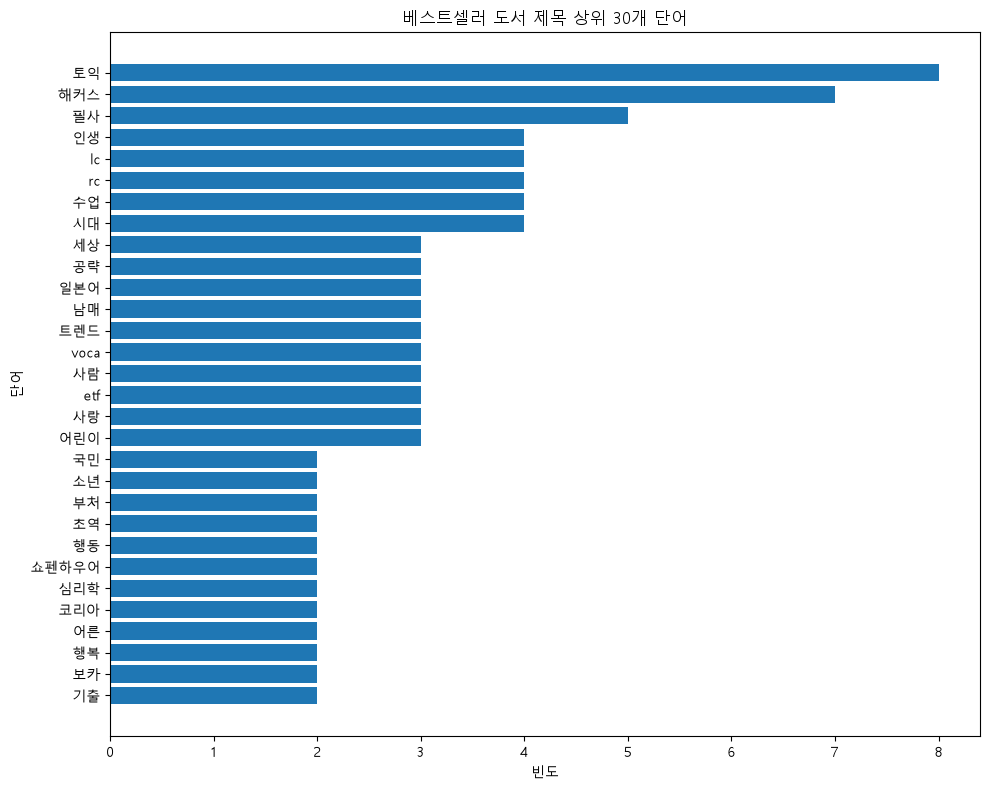

In [22]:
import matplotlib.pyplot as plt

# Windows 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 상위 30개 단어를 빈도 기준으로 오름차순 정렬
# 가로 막대그래프에서는 빈도가 높은 단어가 위쪽에 보이게 하기 위함
plot_data = top30.sort_values("빈도", ascending=True)

# 그래프 크기 설정
plt.figure(figsize=(10, 8))

# 가로 막대그래프 만들기
plt.barh(plot_data["단어"], plot_data["빈도"])

# 축 이름과 제목 설정
plt.xlabel("빈도")
plt.ylabel("단어")
plt.title("베스트셀러 도서 제목 상위 30개 단어")

# 그래프 요소가 겹치지 않도록 정리
plt.tight_layout()

# 그래프 출력
plt.show()

### 실행 결과 요약

- 그래프 생성 확인: 상위 30개 단어의 빈도를 가로 막대그래프로 시각화했다.
- 빈도 확인: `토익`이 8회로 가장 높았고, `해커스` 7회, `필사` 5회가 뒤를 이었다.
- 중간 빈도 확인: `인생`, `수업`, `시대`, `lc`, `rc`는 각각 4회로 나타났다.
- 한글 출력 확인: 그래프의 제목, 축 이름, 한글 단어가 깨지지 않고 정상적으로 표시되었다.
- 결과 검증: 막대 길이가 앞에서 만든 상위 30개 빈도표의 값과 자연스럽게 대응하는 것을 확인했다.

### 실습 20. Word Cloud 설치하기

- 라이브러리 설치: 현재 가상환경에 `wordcloud`와 `matplotlib`을 설치한다.
- 설치 확인: `python -m pip show wordcloud`로 정상 설치 여부를 확인한다.
- Notebook 확인: `from wordcloud import WordCloud`가 오류 없이 실행되는지 확인한다.
- 다음 단계 준비: 설치가 완료되면 최종 단어 빈도를 이용해 Word Cloud를 만들 수 있다.

### 실행 결과 요약

- 설치 완료: `wordcloud` 패키지가 현재 `.venv` 가상환경에 정상적으로 설치되었다.
- 버전 확인: 설치된 `wordcloud` 버전은 `1.9.6`이다.
- 설치 위치 확인: 패키지가 `C:\dev\kant-axagent-study\.venv\Lib\site-packages`에 설치된 것을 확인했다.
- 의존성 확인: `matplotlib`, `numpy`, `pillow` 등 필요한 패키지도 함께 사용할 수 있는 상태이다.
- 결과 확인: `Successfully installed wordcloud-1.9.6`이 출력되어 설치가 정상적으로 완료되었다.

### 실습 21. Word Cloud용 한글 폰트 확인하기

- 한글 폰트 필요: Word Cloud에서 한글을 정상적으로 표시하려면 한글 폰트 파일 경로가 필요하다.
- 경로 확인: Windows에서는 `C:/Windows/Fonts/malgun.ttf` 같은 맑은 고딕 폰트를 사용할 수 있다.
- 파일 존재 확인: `Path().exists()`를 사용해 해당 폰트 파일이 실제로 존재하는지 확인한다.
- 결과 해석: `True`이면 해당 폰트를 사용할 수 있고, `False`이면 다른 한글 폰트 경로를 찾아야 한다.
- 주의점: 폰트 경로는 운영체제와 PC 환경에 따라 달라질 수 있다.

### 실행 결과 요약

- 한글 폰트 확인: Word Cloud에서 사용할 맑은 고딕 폰트 경로를 확인했다.
- 파일 존재 확인: `Path().exists()`를 사용해 해당 폰트 파일이 실제로 존재하는지 확인했다.
- 다음 단계 준비: 확인한 한글 폰트 경로를 Word Cloud 생성 시 사용할 수 있는 상태가 되었다.

### 실습 22. Word Cloud 생성하기

- Word Cloud 생성: `final_counter`의 단어 빈도 데이터를 사용해 Word Cloud를 만든다.
- 한글 폰트 적용: 앞에서 확인한 `FONT_PATH`를 사용해 한글이 깨지지 않도록 설정한다.
- 화면 출력: `plt.imshow()`를 사용해 생성된 Word Cloud를 Notebook에서 확인한다.
- 이미지 저장: 생성한 Word Cloud를 `chapter02_wordcloud.png` 파일로 저장한다.
- 저장 확인: `Path().exists()`를 사용해 이미지 파일이 정상적으로 생성되었는지 확인한다.

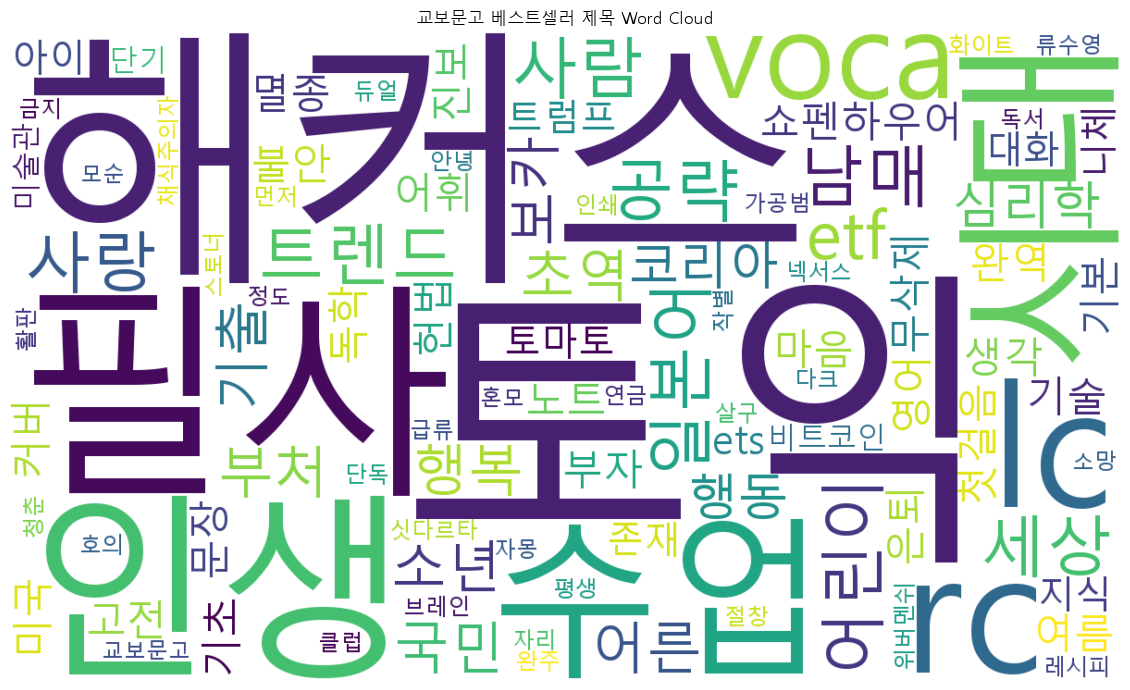

파일 생성 여부: True


In [23]:
from pathlib import Path
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Word Cloud에서 사용할 한글 폰트 경로
FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")

# 단어 빈도 데이터를 이용해 Word Cloud 생성
wordcloud = WordCloud(
    font_path=str(FONT_PATH),
    width=1200,
    height=700,
    background_color="white",
    max_words=100,
    random_state=42,
).generate_from_frequencies(final_counter)

# Word Cloud 화면 출력
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("교보문고 베스트셀러 제목 Word Cloud")
plt.tight_layout()
plt.show()

# 이미지 파일로 저장
wordcloud.to_file("chapter02_wordcloud.png")

# 저장 여부 확인
print("파일 생성 여부:", Path("chapter02_wordcloud.png").exists())

### 실행 결과 요약

- Word Cloud 생성: 최종 단어 빈도 데이터를 이용해 Word Cloud가 정상적으로 생성되었다.
- 한글 출력 확인: 한글 단어가 깨지지 않고 정상적으로 표시되었다.
- 빈도 반영 확인: 빈도가 높은 `토익`, `해커스`, `필사`, `인생` 등의 단어가 더 크게 나타났다.
- 시각적 해석: 막대그래프보다 전체 단어 분포를 한눈에 보기 쉬웠다.
- 결과 확인: 도서 제목에서 자주 등장한 핵심 단어들을 시각적으로 확인할 수 있었다.

### 실습 23. Word Cloud를 어떻게 해석해야 할까?

- 빈도 의미: Word Cloud에서 글자가 크게 보일수록 이번 분석 조건에서 해당 단어가 더 자주 등장했다는 뜻이다.
- 해석 범위: 특정 단어가 크게 보인다면 베스트셀러 도서 제목에서 그 단어가 상대적으로 자주 사용되었다고 해석할 수 있다.
- 주의점: 자주 등장했다고 해서 그 단어가 베스트셀러 판매의 원인이라고 볼 수는 없다.
- 확대 해석 금지: 독자들이 해당 주제의 책을 가장 좋아한다고 단정할 수도 없다.
- 핵심 원칙: 이번 분석은 도서 제목의 단어 빈도를 보는 것이므로, **자주 등장한 단어와 중요한 원인은 같은 개념이 아니다.**

### 실습 24. 상위 단어를 원본 제목에서 다시 확인하기

- 원본 검증: 빈도 상위 단어가 실제 도서 제목에서 어떻게 사용되었는지 다시 확인한다.
- 검색 방법: `str.contains()`를 사용해 해당 단어가 포함된 상품명을 찾고 분야와 함께 확인한다.
- 확인 목적: 같은 단어라도 실제 제목에서는 서로 다른 문맥으로 사용될 수 있기 때문에 원본 데이터를 함께 살펴본다.
- 주의점: 단순 문자열 검색 결과와 형태소 분석 빈도는 합성어, 변형된 표현 등 때문에 정확히 일치하지 않을 수 있다.
- 검증 의미: 이 과정을 통해 단어 빈도 결과를 더 정확하게 이해하고 과도한 해석을 줄일 수 있다.

In [24]:
# 상위 30개 단어 중 가장 많이 등장한 단어 선택
target_word = top30.iloc[0]["단어"]

print("확인할 단어:", target_word)


# 원본 상품명에서 해당 단어가 포함된 제목 찾기
matched_titles = df_books[
    df_books["상품명"].astype(str).str.contains(
        str(target_word),
        case=False,
        na=False,
        regex=False,
    )
][["상품명", "분야"]]


# 결과 확인
print("\n해당 단어가 포함된 원본 제목")
display(matched_titles.head(20))

확인할 단어: 토익

해당 단어가 포함된 원본 제목


,상품명,분야
12,해커스 토익 기출 VOCA(보카),외국어
72,ETS 토익기출 파트별 VOCA,외국어
83,한 권으로 끝내는 해커스 토익 700+(LC+RC+VOCA),외국어
88,해커스 토익 RC Reading(리딩) 기본서,외국어
106,2026 제이크쌤의 28시간에 끝내는 토익스피킹 All in One,외국어
136,해커스 토익 LC Listening(리스닝) 기본서,외국어
153,토익 단기공략 750+(LC+RC),외국어
171,ETS 토익 단기공략 850+(LC+RC),외국어


### 실행 결과 요약

- 상위 단어 확인: 빈도 1위 단어인 `토익`을 원본 제목에서 다시 확인했다.
- 원본 검색 결과: `토익`이 포함된 도서 제목은 여러 개였으며, 확인된 도서는 모두 `외국어` 분야에 속해 있었다.
- 문맥 확인: `토익`은 `기출`, `VOCA`, `LC`, `RC`, `토익스피킹` 등 시험 준비와 관련된 표현과 함께 사용되고 있었다.
- 빈도 해석: `토익`이 자주 등장한 것은 외국어 분야의 토익 관련 도서 제목이 여러 개 포함되어 있기 때문임을 확인했다.
- 검증 의미: 상위 빈도 단어를 원본 제목과 연결해 봄으로써 단어 빈도 결과의 실제 문맥을 확인할 수 있었다.

### 실습 25. 상위 10개 단어의 빈도 합 검증하기

- 상위 10개 검증: `final_counter.most_common(10)` 결과와 `top30.head(10)` 결과의 단어와 빈도가 같은지 비교한다.
- 전체 빈도 검증: `final_counter`의 전체 빈도 합과 `final_words`의 전체 단어 수를 비교한다.
- 확인 기준: 두 값이 같으면 각 단어의 빈도 합이 전체 단어 수와 일치한다는 뜻이다.
- 검증 목적: 코드가 단순히 실행된 것뿐 아니라 빈도 집계 결과가 논리적으로 맞는지도 확인한다.

In [25]:
# 상위 10개 단어와 빈도 확인
top10 = final_counter.most_common(10)

print("Counter 상위 10개")
print(top10)


# top30 DataFrame의 앞 10개와 비교
print("\ntop30 DataFrame 상위 10개")
print(top30.head(10).values.tolist())


# 전체 빈도 합 확인
print("\nCounter 전체 빈도 합")
print(sum(final_counter.values()))


# final_words 전체 단어 수 확인
print("\nfinal_words 길이")
print(len(final_words))

Counter 상위 10개
[('토익', 8), ('해커스', 7), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('voca', 3), ('트렌드', 3)]

top30 DataFrame 상위 10개
[['토익', 8], ['해커스', 7], ['필사', 5], ['인생', 4], ['수업', 4], ['시대', 4], ['lc', 4], ['rc', 4], ['voca', 3], ['트렌드', 3]]

Counter 전체 빈도 합
417

final_words 길이
417


### 실행 결과 요약

- 상위 10개 검증: `Counter`의 상위 10개 결과와 `top30` DataFrame의 상위 10개 결과가 모두 일치했다.
- 빈도 확인: `토익` 8회, `해커스` 7회, `필사` 5회 등 단어와 빈도가 동일하게 나타났다.
- 전체 합 검증: `final_counter`의 전체 빈도 합은 **417**이었다.
- 단어 수 검증: `final_words`의 전체 길이도 **417**이었다.
- 검증 결과: 상위 빈도 결과와 전체 단어 수가 서로 일치해 빈도 집계가 논리적으로 맞는 것을 확인했다.

### 실습 26. 불용어 적용 전후 비교하기

- 적용 전후 비교: 불용어를 적용하기 전 `noun_counter`와 적용 후 `final_counter`의 상위 20개 단어를 비교한다.
- 제거 효과 확인: 불용어로 지정한 단어가 실제 상위 결과에서 사라졌는지 확인한다.
- 중요 단어 확인: 의미 있는 단어까지 함께 제거되지 않았는지 살펴본다.
- 순위 변화 확인: 불용어 적용 전후로 상위 단어의 순위와 빈도가 어떻게 달라졌는지 비교한다.
- 기준 기록: 불용어는 분석 결과에 영향을 주기 때문에 어떤 기준으로 제거했는지 최종 Markdown에 남긴다.

In [26]:
import pandas as pd

# 불용어 적용 전 상위 20개 단어
before_top20 = pd.DataFrame(
    noun_counter.most_common(20),
    columns=["적용 전 단어", "적용 전 빈도"]
)

# 불용어 적용 후 상위 20개 단어
after_top20 = pd.DataFrame(
    final_counter.most_common(20),
    columns=["적용 후 단어", "적용 후 빈도"]
)

# 두 결과를 옆으로 붙여 비교
comparison = pd.concat(
    [before_top20, after_top20],
    axis=1
)

# 결과 확인
print("불용어 적용 전후 비교")
display(comparison)

불용어 적용 전후 비교


,적용 전 단어,적용 전 빈도,적용 후 단어,적용 후 빈도
0,에디션,14,토익,8
1,기념,10,해커스,7
2,토익,8,필사,5
3,해커스,7,인생,4
4,리커버,7,수업,4
5,스페셜,5,시대,4
6,필사,5,lc,4
7,인생,4,rc,4
8,수업,4,voca,3
9,시대,4,트렌드,3


### 실행 결과 요약

- 불용어 적용 전: `에디션` 14회, `기념` 10회, `리커버` 7회, `스페셜` 5회, `특별` 3회, `한정판` 3회처럼 판형·마케팅 성격의 표현이 상위에 포함되어 있었다.
- 불용어 적용 후: 위 표현들이 상위 결과에서 사라지고 `토익`, `해커스`, `필사`, `인생`, `수업`, `시대` 등이 상위에 나타났다.
- 순위 변화 확인: `토익`은 적용 전 3위에서 적용 후 1위로, `해커스`는 4위에서 2위로 올라갔다.
- 중요한 단어 유지: `토익`, `해커스`, `필사`, `인생`, `수업`, `시대` 등 분석에 의미가 있는 단어들은 그대로 남아 있었다.
- 결과 판단: 불용어 제거를 통해 판형·마케팅 관련 표현의 영향은 줄이고, 도서 내용이나 주제와 관련된 단어를 더 잘 확인할 수 있게 되었다.

### 실습27. 인공지능에게 결과 해석 요청하기

### 분석 결과 요약

Kiwi 형태소 분석을 사용해 일반 명사(`NNG`), 고유 명사(`NNP`), 영문 토큰(`SL`) 중 2글자 이상인 단어를 추출하고 불용어를 제거했다.  
상위 10개 단어는 `토익` 8회, `해커스` 7회, `필사` 5회, `인생`·`수업`·`시대`·`lc`·`rc`가 각각 4회, `voca`와 `트렌드`가 각각 3회로 나타났다.  
이를 통해 이번 베스트셀러 제목 데이터에서는 외국어 학습과 관련된 표현과 함께 `필사`, `인생`, `수업`, `시대` 같은 단어도 반복해서 등장했음을 확인할 수 있었다.  
다만 이 결과는 도서 제목에 등장한 단어의 빈도를 보여주는 것이므로, 해당 주제가 실제 판매를 증가시킨 원인이라고 해석할 수는 없다.  
또한 형태소 분석 결과와 불용어 기준에 따라 단어 빈도가 달라질 수 있으므로, 이번 결과는 설정한 분석 조건 안에서 해석해야 한다.

### 실습28. 결과 Markdwon 작성하기

### 단어 빈도 분석 결과

교보문고 베스트셀러 도서 제목을 대상으로 단어 빈도를 확인했다.

Kiwi 형태소 분석기를 이용해 일반 명사(`NNG`), 고유 명사(`NNP`), 영문 토큰(`SL`)을 추출했고, 2글자 이상 단어만 사용한 뒤 분석 목적과 관계가 적은 일부 표현을 불용어로 제거했다.

빈도 상위 단어는 다음과 같았다.

- 1위: `토익` (8회)
- 2위: `해커스` (7회)
- 3위: `필사` (5회)

Word Cloud에서도 빈도가 높은 단어가 상대적으로 크게 표시되는 것을 확인했다.

다만 이 결과는 도서 제목에서 자주 등장한 단어를 보여주는 것이며, 해당 단어가 도서 판매의 원인이라는 의미는 아니다.